In [550]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [551]:
df = pd.read_csv('ADAS_EV_Dataset.csv')
df


,timestamp,speed_kmh,acceleration_mps2,brake_intensity,battery_level,energy_consumption,regen_braking_usage,lane_deviation,obstacle_distance,traffic_density,weather_condition,road_type,steering_angle,reaction_time,ADAS_output
0,2023-01-01 00:00:00,44.944814,-0.758155,0.729998,65.623734,0.667933,84.723658,0.966221,4.266110,41,Rainy,Highway,13.582336,2.094568,Brake
1,2023-01-01 00:00:01,114.085717,-1.002527,0.184512,48.632783,0.280154,49.451704,1.524408,82.850462,23,Foggy,Urban,-11.512973,2.318870,Lane Correct
2,2023-01-01 00:00:02,87.839273,-1.943077,0.346640,96.627360,0.340083,19.546561,-0.147280,24.930758,12,Rainy,Rural,-22.073883,2.128859,Maintain Speed
3,2023-01-01 00:00:03,71.839018,0.643600,0.663281,25.802953,0.443275,73.664179,-0.843285,28.393736,34,Sunny,Highway,-9.533481,0.497469,Maintain Speed
4,2023-01-01 00:00:04,18.722237,-0.140255,0.482089,60.846360,0.486941,41.867814,-0.724614,22.624528,15,Sunny,Urban,2.728121,0.959573,Accelerate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2023-01-01 02:46:35,102.918719,2.262232,0.952275,76.633221,1.282646,96.614073,0.377586,32.212906,21,Rainy,Highway,23.120043,0.972454,Maintain Speed
9996,2023-01-01 02:46:36,107.701060,-2.719116,0.747824,77.630059,0.529768,37.323996,1.786463,37.462624,48,Rainy,Urban,16.846138,1.659061,Lane Correct
9997,2023-01-01 02:46:37,113.604950,-1.177809,0.019456,30.609096,1.523091,30.467486,1.683674,38.170174,41,Snowy,Urban,-10.221705,2.219454,Lane Correct
9998,2023-01-01 02:46:38,47.698559,-0.340080,0.401005,46.260378,1.089921,40.736253,-1.198143,12.963225,31,Rainy,Urban,-6.383439,2.137634,Maintain Speed


In [552]:
df.shape

(10000, 15)

In [553]:
df.columns

Index(['timestamp', 'speed_kmh', 'acceleration_mps2', 'brake_intensity',
       'battery_level', 'energy_consumption', 'regen_braking_usage',
       'lane_deviation', 'obstacle_distance', 'traffic_density',
       'weather_condition', 'road_type', 'steering_angle', 'reaction_time',
       'ADAS_output'],
      dtype='object')

# Preproccesing

In [554]:
df.isna().any()

,0
timestamp,False
speed_kmh,False
acceleration_mps2,False
brake_intensity,False
battery_level,False
energy_consumption,False
regen_braking_usage,False
lane_deviation,False
obstacle_distance,False
traffic_density,False


In [555]:
from sklearn.preprocessing import LabelEncoder
# Encode categorical variables
label_encoders = {}
categorical_columns = ['weather_condition', 'road_type', 'ADAS_output']

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"\n{col} classes:", le.classes_)


weather_condition classes: ['Foggy' 'Rainy' 'Snowy' 'Sunny']

road_type classes: ['Highway' 'Rural' 'Urban']

ADAS_output classes: ['Accelerate' 'Brake' 'Lane Correct' 'Maintain Speed']


# Original DataFrame
#    weather_condition  road_type     ADAS_output
# 0              foggy      highway     Accelerate
# 1              rainy      rural          Brake
# 2              snowy      urban     Lane Corrected
# 3              sunny                Maintain Speed

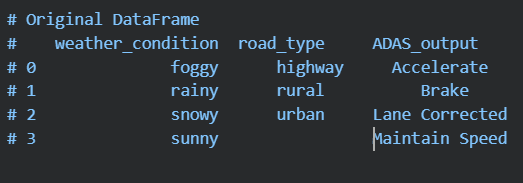

In [556]:

# X = df.drop(['timestamp', 'ADAS_output'], axis=1)
# y = df['ADAS_output']

X = df.iloc[:, 1:-1].values
y = df.iloc[:, -1].values

df

,timestamp,speed_kmh,acceleration_mps2,brake_intensity,battery_level,energy_consumption,regen_braking_usage,lane_deviation,obstacle_distance,traffic_density,weather_condition,road_type,steering_angle,reaction_time,ADAS_output
0,2023-01-01 00:00:00,44.944814,-0.758155,0.729998,65.623734,0.667933,84.723658,0.966221,4.266110,41,1,0,13.582336,2.094568,1
1,2023-01-01 00:00:01,114.085717,-1.002527,0.184512,48.632783,0.280154,49.451704,1.524408,82.850462,23,0,2,-11.512973,2.318870,2
2,2023-01-01 00:00:02,87.839273,-1.943077,0.346640,96.627360,0.340083,19.546561,-0.147280,24.930758,12,1,1,-22.073883,2.128859,3
3,2023-01-01 00:00:03,71.839018,0.643600,0.663281,25.802953,0.443275,73.664179,-0.843285,28.393736,34,3,0,-9.533481,0.497469,3
4,2023-01-01 00:00:04,18.722237,-0.140255,0.482089,60.846360,0.486941,41.867814,-0.724614,22.624528,15,3,2,2.728121,0.959573,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2023-01-01 02:46:35,102.918719,2.262232,0.952275,76.633221,1.282646,96.614073,0.377586,32.212906,21,1,0,23.120043,0.972454,3
9996,2023-01-01 02:46:36,107.701060,-2.719116,0.747824,77.630059,0.529768,37.323996,1.786463,37.462624,48,1,2,16.846138,1.659061,2
9997,2023-01-01 02:46:37,113.604950,-1.177809,0.019456,30.609096,1.523091,30.467486,1.683674,38.170174,41,2,2,-10.221705,2.219454,2
9998,2023-01-01 02:46:38,47.698559,-0.340080,0.401005,46.260378,1.089921,40.736253,-1.198143,12.963225,31,1,2,-6.383439,2.137634,3


ADAS_output            1.000000
speed_kmh              0.582071
obstacle_distance      0.151809
acceleration_mps2      0.011550
reaction_time          0.008867
steering_angle         0.007962
weather_condition      0.003024
traffic_density        0.002960
road_type             -0.003599
lane_deviation        -0.007246
energy_consumption    -0.009288
brake_intensity       -0.012453
regen_braking_usage   -0.014655
battery_level         -0.109983
Name: ADAS_output, dtype: float64


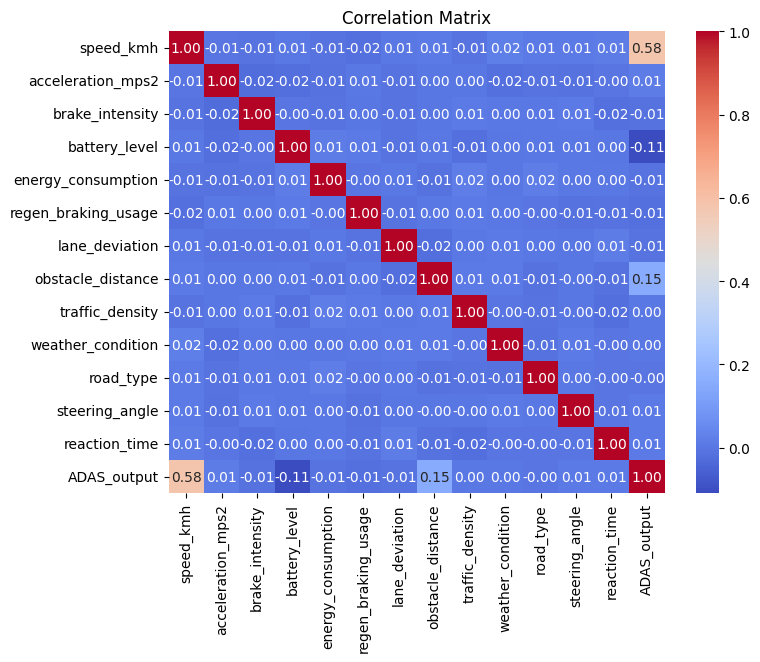

In [557]:
import seaborn as sns

corr = df.drop('timestamp', axis=1).corr()

corr_target = corr['ADAS_output'].sort_values(ascending=False)
print(corr_target)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [558]:
from sklearn.model_selection import train_test_split
X = df.iloc[:, 1:-1].values
y = df.iloc[:, -1].values
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [559]:
print(X_train)

[[ 1.14856180e+02 -5.32063819e-01  3.76122431e-01 ...  1.00000000e+00
  -7.55206469e+00  1.46550994e+00]
 [ 6.91819771e+01 -2.87832016e+00  6.40964396e-01 ...  2.00000000e+00
  -1.24044044e+01  1.69539612e+00]
 [ 6.97103425e+00  1.57984846e+00  2.79331019e-01 ...  2.00000000e+00
   1.82349492e+01  2.16665443e+00]
 ...
 [ 7.41905726e+01  2.77374925e+00  3.89413543e-01 ...  2.00000000e+00
   1.96515910e+01  1.20089384e+00]
 [ 1.28185192e+01 -2.44260171e+00  6.17054195e-01 ...  1.00000000e+00
  -2.05855248e+01  1.49319860e+00]
 [ 8.04304771e+01 -6.50388714e-01  9.35130664e-02 ...  2.00000000e+00
  -2.54477177e+01  1.99900234e+00]]


In [560]:
print(X_test)

[[ 1.51757094e+01  1.11243974e+00  2.14087469e-01 ...  2.00000000e+00
  -2.68092890e+01  1.57258098e+00]
 [ 2.67179082e+01  2.88931043e+00  4.25435293e-01 ...  2.00000000e+00
   1.34488645e+01  2.01885397e+00]
 [ 1.16927377e+02 -1.21174981e+00  6.02896339e-01 ...  1.00000000e+00
  -8.30720974e+00  2.08566733e+00]
 ...
 [ 5.31752814e+01  5.46372468e-01  3.53410446e-02 ...  2.00000000e+00
  -2.76532569e+01  6.68286105e-01]
 [ 1.06816936e+02  2.24745886e+00  9.82802540e-01 ...  2.00000000e+00
   1.25257616e+01  9.31042478e-01]
 [ 1.14556518e+02 -1.30759425e+00  3.38326270e-01 ...  1.00000000e+00
   5.13332004e+00  2.11686379e+00]]


In [561]:
print(X_train)

[[ 1.14856180e+02 -5.32063819e-01  3.76122431e-01 ...  1.00000000e+00
  -7.55206469e+00  1.46550994e+00]
 [ 6.91819771e+01 -2.87832016e+00  6.40964396e-01 ...  2.00000000e+00
  -1.24044044e+01  1.69539612e+00]
 [ 6.97103425e+00  1.57984846e+00  2.79331019e-01 ...  2.00000000e+00
   1.82349492e+01  2.16665443e+00]
 ...
 [ 7.41905726e+01  2.77374925e+00  3.89413543e-01 ...  2.00000000e+00
   1.96515910e+01  1.20089384e+00]
 [ 1.28185192e+01 -2.44260171e+00  6.17054195e-01 ...  1.00000000e+00
  -2.05855248e+01  1.49319860e+00]
 [ 8.04304771e+01 -6.50388714e-01  9.35130664e-02 ...  2.00000000e+00
  -2.54477177e+01  1.99900234e+00]]


In [562]:
print(X_test)

[[ 1.51757094e+01  1.11243974e+00  2.14087469e-01 ...  2.00000000e+00
  -2.68092890e+01  1.57258098e+00]
 [ 2.67179082e+01  2.88931043e+00  4.25435293e-01 ...  2.00000000e+00
   1.34488645e+01  2.01885397e+00]
 [ 1.16927377e+02 -1.21174981e+00  6.02896339e-01 ...  1.00000000e+00
  -8.30720974e+00  2.08566733e+00]
 ...
 [ 5.31752814e+01  5.46372468e-01  3.53410446e-02 ...  2.00000000e+00
  -2.76532569e+01  6.68286105e-01]
 [ 1.06816936e+02  2.24745886e+00  9.82802540e-01 ...  2.00000000e+00
   1.25257616e+01  9.31042478e-01]
 [ 1.14556518e+02 -1.30759425e+00  3.38326270e-01 ...  1.00000000e+00
   5.13332004e+00  2.11686379e+00]]


In [563]:
print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")


Training set size: (8000, 13)
Test set size: (2000, 13)


# Random Forest

Accuracy: 0.9985

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       389
           1       1.00      1.00      1.00       191
           2       1.00      0.99      1.00       348
           3       1.00      1.00      1.00      1072

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



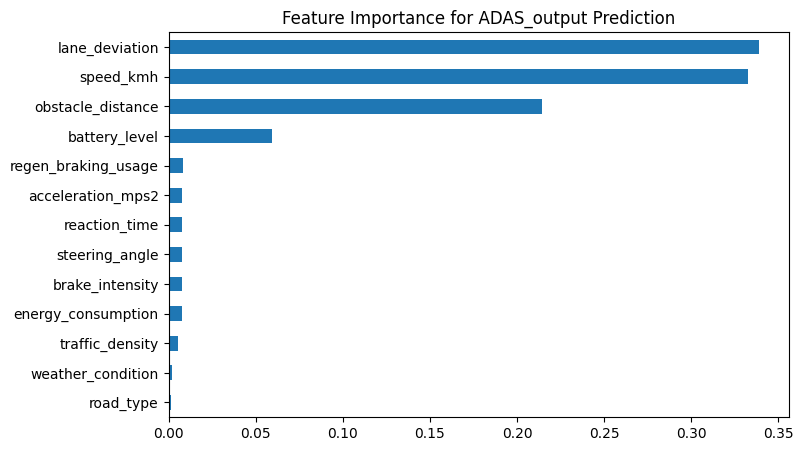

In [564]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ADAS_EV_Dataset.csv')
df.columns = df.columns.str.strip()

# Encode categorical variables
label_encoders = {}
categorical_columns = ['weather_condition', 'road_type', 'ADAS_output']

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define features (X) and target (y) for multi-class classification
target_col = 'ADAS_output'
X = df.drop(['timestamp', target_col], axis=1)
y = df[target_col]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature importance
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=True).plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance for ADAS_output Prediction")
plt.show()

In [565]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

misclassification_error = 1 - accuracy

print("Misclassification Error:", misclassification_error)


Misclassification Error: 0.0014999999999999458


In [566]:
train_pred = rf_model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Both Training and Testing accuracy is Equal then its Not OverFitting")


Train Accuracy: 1.0
Test Accuracy: 0.9985
Both Training and Testing accuracy is Equal then its Not OverFitting


In [567]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("CV accuracy close to test accuracy → Model is stable")


Cross-Validation Scores: [0.999 1.    1.    1.    0.999]
Mean CV Accuracy: 0.9996
CV accuracy close to test accuracy → Model is stable


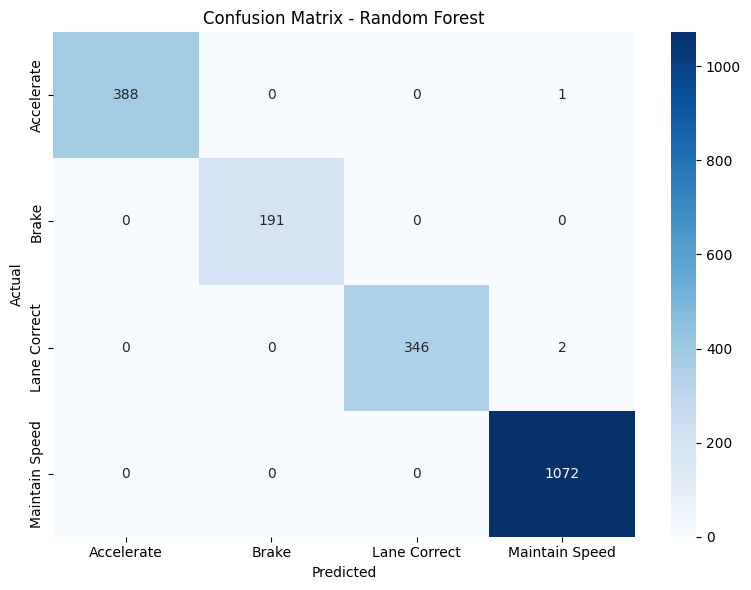

In [568]:
# Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoders['ADAS_output'].classes_,
    yticklabels=label_encoders['ADAS_output'].classes_
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


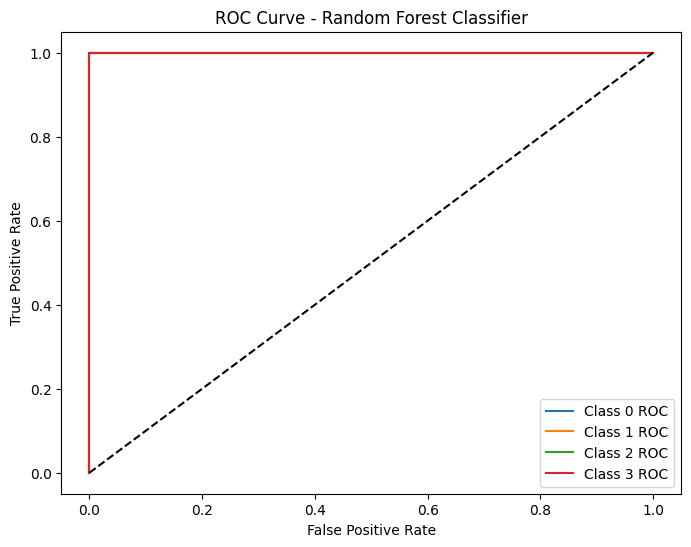

In [569]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Binarize target labels for multi-class ROC
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# Predict probabilities
y_prob = rf_model.predict_proba(X_test)

plt.figure(figsize=(8, 6))

# Plot ROC curve for each class
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} ROC")

# Reference diagonal line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Classifier")
plt.legend()
plt.show()


In [570]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize labels
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# Predict probabilities
y_prob = rf_model.predict_proba(X_test)

# Print AUC for each class
for i in range(len(classes)):
    auc_score = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    print(f"AUC for Class {i}: {auc_score:.3f}")


AUC for Class 0: 1.000
AUC for Class 1: 1.000
AUC for Class 2: 1.000
AUC for Class 3: 1.000


# Decision Trees

In [571]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ADAS_EV_Dataset.csv')
df.columns = df.columns.str.strip()

# Encode categorical variables
label_encoders = {}
categorical_columns = ['weather_condition', 'road_type', 'ADAS_output']

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

target_col = 'ADAS_output'
X = df.drop(['timestamp', target_col], axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

dtc_model = DecisionTreeClassifier(random_state=42)

dtc_model.fit(X_train, y_train)

y_pred = dtc_model.predict(X_test)

print(" Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


 Accuracy: 0.998

Confusion Matrix:
 [[ 387    0    0    2]
 [   0  191    0    0]
 [   0    0  346    2]
 [   0    0    0 1072]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       389
           1       1.00      1.00      1.00       191
           2       1.00      0.99      1.00       348
           3       1.00      1.00      1.00      1072

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [572]:
train_pred = dtc_model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Train Acc ≈ Test Acc → Not overfitting")

Train Accuracy: 1.0
Test Accuracy: 0.998
Train Acc ≈ Test Acc → Not overfitting


In [573]:
from sklearn.metrics import accuracy_score

# Already have y_test and y_pred

accuracy = accuracy_score(y_test, y_pred)

misclassification_error = 1 - accuracy

print("Misclassification Error:", misclassification_error)


Misclassification Error: 0.0020000000000000018


In [574]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(dtc_model, X, y, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())
print("CV score ≈ Test accuracy → Model is stable")

Cross-Validation Scores: [0.9985 0.9995 1.     1.     0.998 ]
Mean CV Score: 0.9992000000000001
CV score ≈ Test accuracy → Model is stable


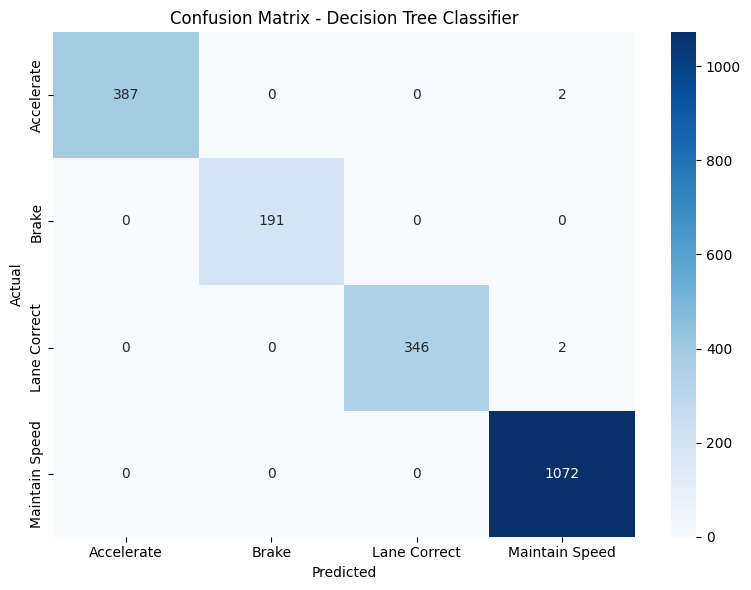

In [575]:
# Confusion Matrix (Decision Tree)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoders['ADAS_output'].classes_,
    yticklabels=label_encoders['ADAS_output'].classes_
)

plt.title("Confusion Matrix - Decision Tree Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [576]:
for test_size in [0.1,0.2, 0.25, 0.3,0.4,0.5]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    dtc = DecisionTreeClassifier(random_state=42)
    dtc.fit(X_train, y_train)

    pred = dtc.predict(X_test)
    print(f"Test Size = {test_size} → Accuracy = {accuracy_score(y_test, pred):.4f}")


Test Size = 0.1 → Accuracy = 1.0000
Test Size = 0.2 → Accuracy = 0.9980
Test Size = 0.25 → Accuracy = 0.9980
Test Size = 0.3 → Accuracy = 0.9983
Test Size = 0.4 → Accuracy = 0.9982
Test Size = 0.5 → Accuracy = 0.9972


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


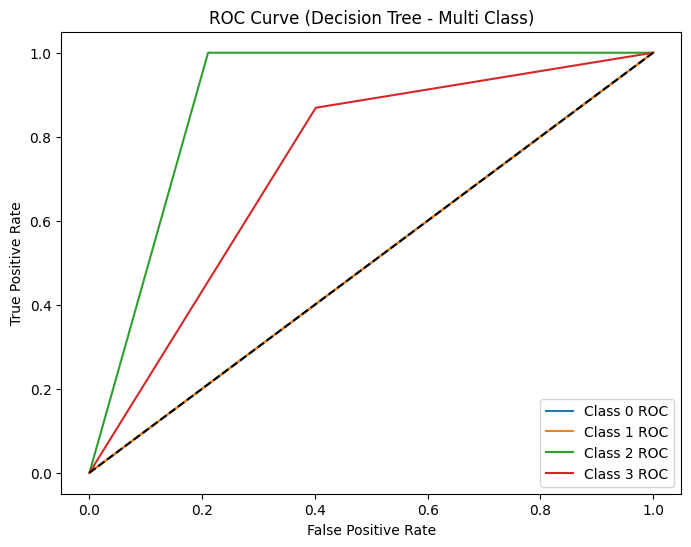

In [577]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Convert y_test into binary form for multi-class ROC
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# Predict probabilities
y_prob = dtc_model.predict_proba(X_test)

plt.figure(figsize=(8, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} ROC")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Decision Tree - Multi Class)")
plt.legend()
plt.show()


In [578]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred = dt_model.predict(X_test_scaled)

# -------- HOLD-OUT ACCURACY --------
holdout_accuracy = accuracy_score(y_test, y_pred)
holdout_misclassification_error = 1 - holdout_accuracy

print("Hold-Out Accuracy:", round(holdout_accuracy, 4))
print("Hold-Out Misclassification Error:", round(holdout_misclassification_error, 4))


Hold-Out Accuracy: 0.998
Hold-Out Misclassification Error: 0.002


In [579]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize target labels
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# Predict probabilities
y_prob = dtc_model.predict_proba(X_test)

# Print AUC for each class
for i in range(len(classes)):
    auc_score = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    print(f"AUC for Class {i}: {auc_score:.3f}")


AUC for Class 0: 0.500
AUC for Class 1: 0.500
AUC for Class 2: 0.898
AUC for Class 3: 0.725


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


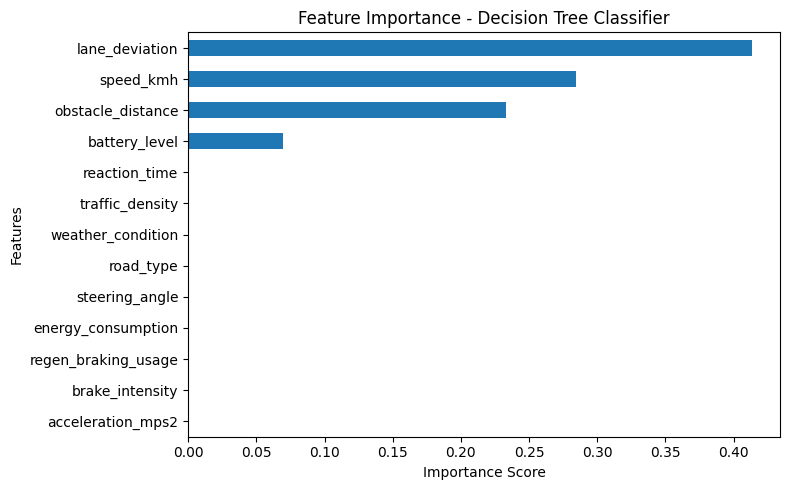

In [580]:
# Feature Importance for Decision Tree
import matplotlib.pyplot as plt
import pandas as pd

feature_importances = pd.Series(dtc_model.feature_importances_, index=X.columns)

# Sort and plot
plt.figure(figsize=(8, 5))
feature_importances.sort_values().plot(kind='barh')

plt.title("Feature Importance - Decision Tree Classifier")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


# Logistic Regression

ADAS_output
Maintain Speed    5358
Accelerate        1947
Lane Correct      1741
Brake              954
Name: count, dtype: int64

Target Classes:
0: Accelerate
1: Brake
2: Lane Correct
3: Maintain Speed

X shape: (10000, 16)
y shape: (10000,)

Accuracy: 0.7747

Classification Report:
                precision    recall  f1-score   support

    Accelerate       0.86      0.89      0.87       584
         Brake       0.91      0.97      0.94       286
  Lane Correct       0.00      0.00      0.00       522
Maintain Speed       0.73      0.95      0.83      1608

      accuracy                           0.77      3000
     macro avg       0.62      0.70      0.66      3000
  weighted avg       0.65      0.77      0.70      3000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: 

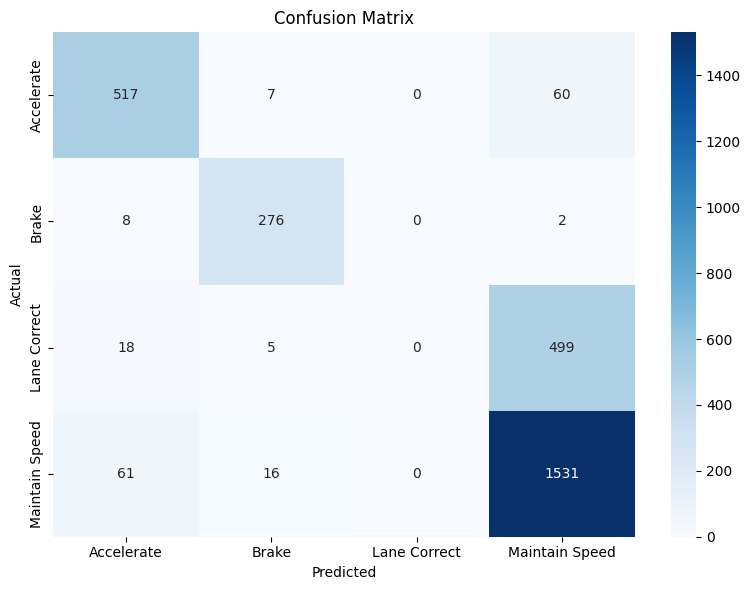


Top 10 Important Features:
                feature  importance
0             speed_kmh    4.509307
7     obstacle_distance    4.374032
3         battery_level    0.830905
1     acceleration_mps2    0.089966
6        lane_deviation    0.078834
8       traffic_density    0.064657
10        reaction_time    0.051176
2       brake_intensity    0.048617
15      road_type_Urban    0.047107
5   regen_braking_usage    0.028901


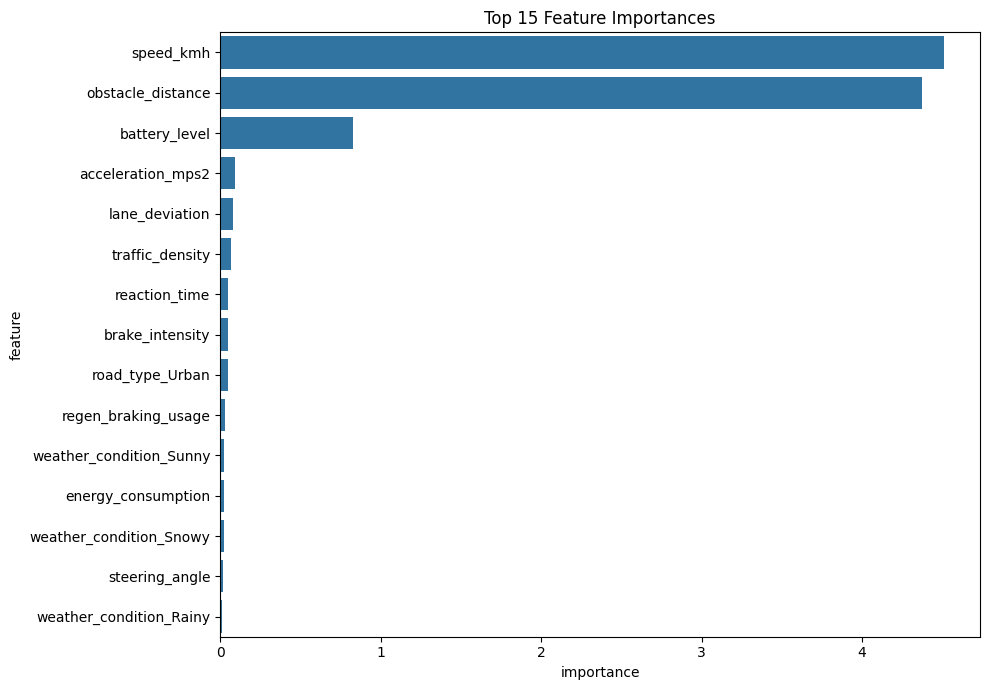


Accuracy by Class:
Accelerate: 0.8853
Brake: 0.9650
Lane Correct: 0.0000
Maintain Speed: 0.9521
ADDITIONAL ANALYSIS

Accuracy by Road Type:
Highway: 0.7859
Rural: 0.7671
Urban: 0.7705


In [581]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('ADAS_EV_Dataset.csv')

print(df['ADAS_output'].value_counts())


# Store original road_type for analysis later, before one-hot encoding
original_road_type_series = df['road_type'].copy()

# One-hot encode categorical columns
df = pd.get_dummies(df, columns=['weather_condition', 'road_type'], drop_first=True)

# Label encode target
le = LabelEncoder()
df['ADAS_output_encoded'] = le.fit_transform(df['ADAS_output'])

print("\nTarget Classes:")
for i, cls in enumerate(le.classes_):
    print(f"{i}: {cls}")

# Features (X) and Target (y)
X = df.drop(['timestamp', 'ADAS_output', 'ADAS_output_encoded'], axis=1)
y = df['ADAS_output_encoded']

print("\nX shape:", X.shape)
print("y shape:", y.shape)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(multi_class='multinomial',
                           solver='lbfgs',
                           max_iter=1000,
                           random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# Feature Importance

coef = np.abs(model.coef_[0])

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": coef
}).sort_values("importance", ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))

plt.figure(figsize=(10, 7))
sns.barplot(data=importance.head(15),
            x="importance",
            y="feature")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()


# Accuracy per Class

print("\nAccuracy by Class:")
for i, cls in enumerate(le.classes_):
    mask = (y_test == i)
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred[mask])
        print(f"{cls}: {acc:.4f}")

print("ADDITIONAL ANALYSIS")
# Retrieve original road_type for the test set using the stored series and y_test index
test_road_types = original_road_type_series.loc[y_test.index]

# Create a temporary DataFrame for analysis results
temp_analysis_df = pd.DataFrame({
    'actual': le.inverse_transform(y_test),
    'pred': le.inverse_transform(y_pred),
    'road_type': test_road_types
})

print("\nAccuracy by Road Type:")
for road in temp_analysis_df['road_type'].unique():
    mask = (temp_analysis_df['road_type'] == road)
    acc = accuracy_score(temp_analysis_df.loc[mask, 'actual'], temp_analysis_df.loc[mask, 'pred'])
    print(f"{road}: {acc:.4f}")


In [582]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegression(max_iter=1000)

cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

print("Cross Validation Accuracies for each fold:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores).round(4))
print("Standard Deviation:", np.std(cv_scores).round(4))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross Validation Accuracies for each fold: [0.768  0.775  0.768  0.768  0.7815]
Mean CV Accuracy: 0.7721
Standard Deviation: 0.0054


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [583]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

holdout_acc = accuracy_score(y_test, y_pred)
holdout_mce = 1 - holdout_acc

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

cv_mean_acc = np.mean(cv_scores)
cv_std_acc = np.std(cv_scores)
cv_mean_mce = 1 - cv_mean_acc
cv_std_mce = np.std(1 - cv_scores)

comparison_df = pd.DataFrame({
    "Method": ["Hold-Out (80/20)", "5-Fold CV"],
    "Mean Accuracy": [holdout_acc, cv_mean_acc],
    "Std Accuracy": [0, cv_std_acc],
    "Mean MCE": [holdout_mce, cv_mean_mce],
    "Std MCE": [0, cv_std_mce]
})

display(comparison_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,Method,Mean Accuracy,Std Accuracy,Mean MCE,Std MCE
0,Hold-Out (80/20),0.7710,0.000000,0.2290,0.000000
1,5-Fold CV,0.7721,0.005426,0.2279,0.005426


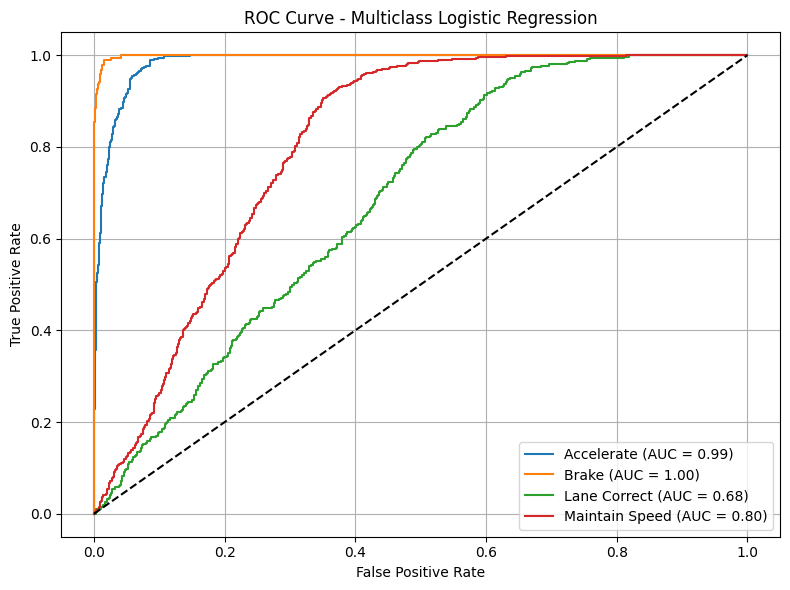

In [584]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize the output for multiclass ROC
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
n_classes = y_test_bin.shape[1]

# Get predicted probabilities from logistic regression
y_score = model.predict_proba(X_test)

plt.figure(figsize=(8, 6))

# Plot ROC for each class
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.2f})")

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC Curve - Multiclass Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [585]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize labels for multiclass AUC
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))

# Predicted probabilities
y_score = model.predict_proba(X_test)

# Compute AUC (macro-average and micro-average)
auc_macro = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
auc_micro = roc_auc_score(y_test_bin, y_score, average="micro", multi_class="ovr")

print("\n===== AUC Scores (Logistic Regression) =====")
print(f"Macro AUC: {auc_macro:.4f}")
print(f"Micro AUC: {auc_micro:.4f}")



===== AUC Scores (Logistic Regression) =====
Macro AUC: 0.8685
Micro AUC: 0.9389


# XGBoost

 Accuracy: 0.989

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       389
           1       0.97      0.99      0.98       191
           2       0.99      0.99      0.99       348
           3       0.99      0.99      0.99      1072

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



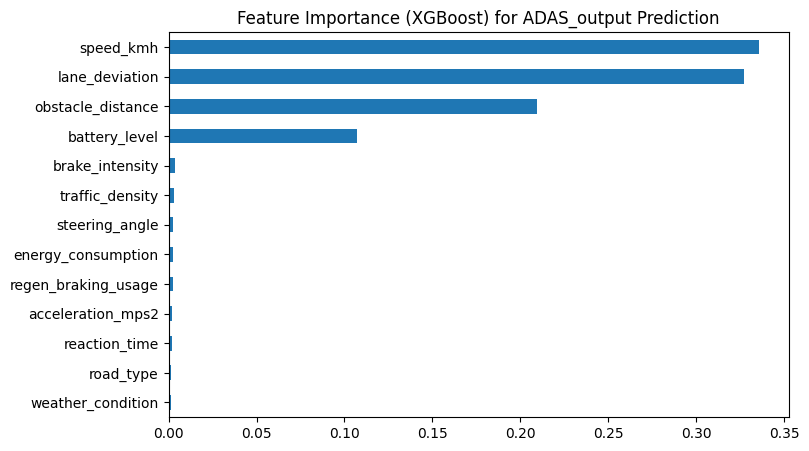

In [586]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier


df = pd.read_csv('ADAS_EV_Dataset.csv')
df.columns = df.columns.str.strip()

label_encoders = {}
categorical_columns = ['weather_condition', 'road_type', 'ADAS_output']

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

target_col = 'ADAS_output'
X = df.drop(['timestamp', target_col], axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Initialize XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective='multi:softmax',   # because it's multi-class classification
    num_class=len(df[target_col].unique())
)


xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Evaluate model
print(" Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature Importance
importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=True).plot(kind='barh', figsize=(8, 5))
plt.title("Feature Importance (XGBoost) for ADAS_output Prediction")
plt.show()


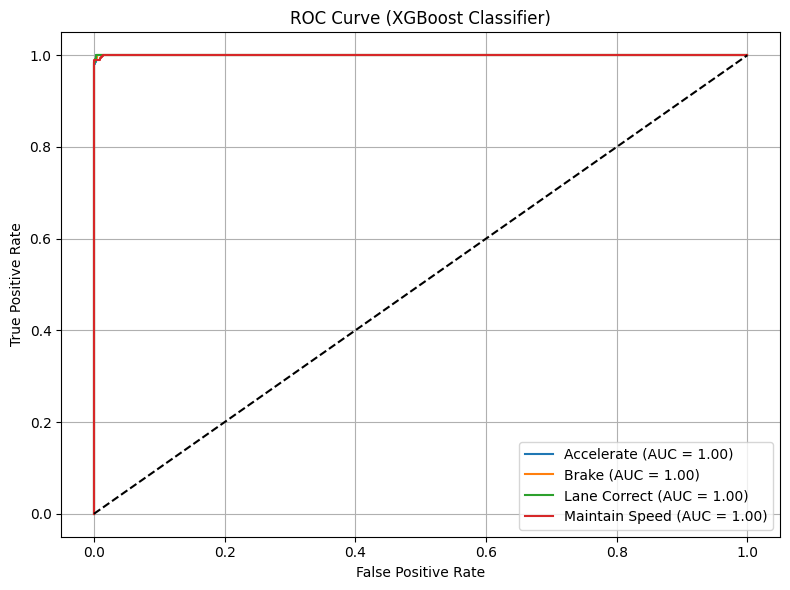

In [587]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the target labels for multiclass ROC
y_test_bin = label_binarize(y_test, classes=range(len(label_encoders['ADAS_output'].classes_)))

# Predicted probabilities
y_score = xgb_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(label_encoders['ADAS_output'].classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

# Plot formatting
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.title("ROC Curve (XGBoost Classifier)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# KNN

K = 1, Accuracy = 0.5770
K = 2, Accuracy = 0.5810
K = 3, Accuracy = 0.6020
K = 4, Accuracy = 0.6300
K = 5, Accuracy = 0.6290
K = 6, Accuracy = 0.6330
K = 7, Accuracy = 0.6390
K = 8, Accuracy = 0.6400
K = 9, Accuracy = 0.6500
K = 10, Accuracy = 0.6490
K = 11, Accuracy = 0.6510
K = 12, Accuracy = 0.6500
K = 13, Accuracy = 0.6460
K = 14, Accuracy = 0.6420
K = 15, Accuracy = 0.6450
K = 16, Accuracy = 0.6480
K = 17, Accuracy = 0.6460
K = 18, Accuracy = 0.6490
K = 19, Accuracy = 0.6410
K = 20, Accuracy = 0.6430


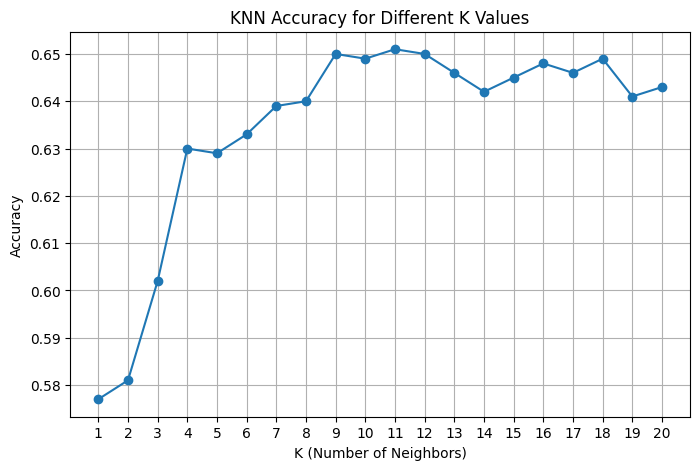


Best K = 11 with Accuracy = 0.6510

Classification Report (Best K):
                precision    recall  f1-score   support

    Accelerate       0.69      0.61      0.65       205
         Brake       0.64      0.16      0.26       100
  Lane Correct       0.77      0.16      0.26       173
Maintain Speed       0.64      0.92      0.75       522

      accuracy                           0.65      1000
     macro avg       0.68      0.46      0.48      1000
  weighted avg       0.67      0.65      0.60      1000



In [588]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


df = pd.read_csv('ADAS_EV_Dataset.csv')

X = df.drop(['ADAS_output', 'timestamp'], axis=1)
y = df['ADAS_output']

# One-hot encode categorical columns
categorical_cols = ['weather_condition', 'road_type']
X = pd.get_dummies(X, columns=categorical_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K = {k}, Accuracy = {acc:.4f}")

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.title('KNN Accuracy for Different K Values')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"\nBest K = {best_k} with Accuracy = {max(accuracies):.4f}")

# Train final model
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

y_pred_final = knn_best.predict(X_test_scaled)
print("\nClassification Report (Best K):")
print(classification_report(y_test, y_pred_final))


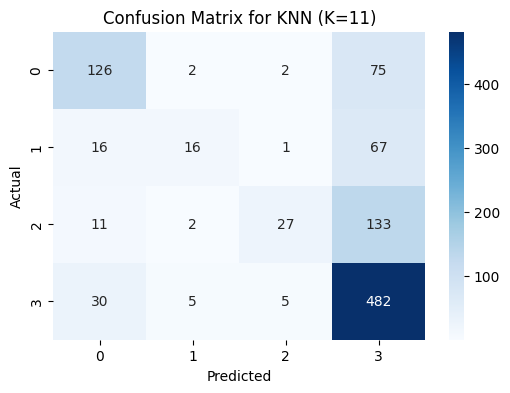

In [589]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix for KNN (K={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


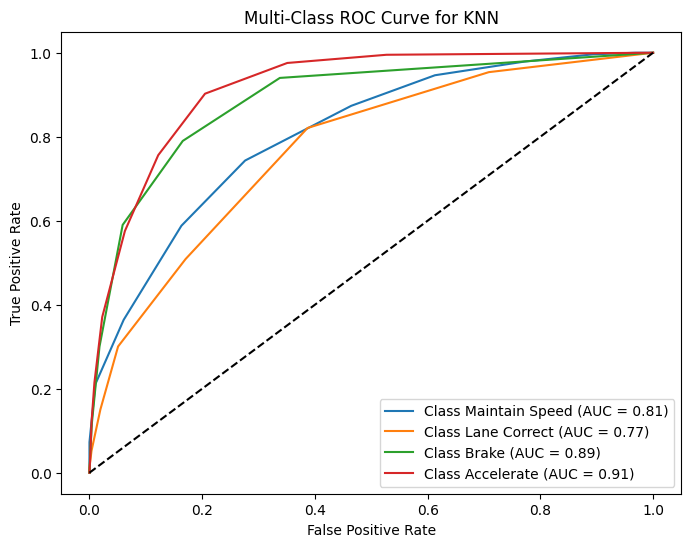

In [590]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Binarize the labels for multi-class ROC
classes = y_train.unique()
y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_train_bin.shape[1]

# Train KNN in One-vs-Rest mode
knn_ovr = OneVsRestClassifier(KNeighborsClassifier(n_neighbors=best_k))
knn_ovr.fit(X_train_scaled, y_train_bin)

# Predict probabilities
y_score = knn_ovr.predict_proba(X_test_scaled)

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

# Plot formatting
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve for KNN')
plt.legend()
plt.show()


In [591]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)


y_pred = knn.predict(X_test_scaled)


holdout_accuracy = accuracy_score(y_test, y_pred)
holdout_mce = 1 - holdout_accuracy

print(f"Hold-Out Accuracy (K={k}):", round(holdout_accuracy, 4))
print(f"Hold-Out Misclassification Error (K={k}):", round(holdout_mce, 4))


Hold-Out Accuracy (K=5): 0.643
Hold-Out Misclassification Error (K=5): 0.357
